# Neuron behavior analysis — single session

Hypothesis: neurons with high **across-hemisphere** shared variance carry
stimulus-related information in bilateral mice but not in unilateral mice.

This notebook loads one already-fit session, filters neurons in each
hemisphere by %shared variance, and builds a trial x variable table per
hemisphere (spike counts for the high-psv neurons + stimulus/choice/outcome/
locomotion/whisker-kinematic/lick-latency variables) for visual inspection.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

from tools.load_session import load_session
from tools.trial_epoching import compute_derived
from tools.neuron_behavior_analysis import (
    load_saved_session,
    base_session_id,
    build_trial_variable_table,
)
from tools.plotting_fncs import plot_neuron_by_category, plot_neuron_vs_continuous

## Config

In [3]:
session_id = 'P1_w0.0-1.0'   # must match a saved results/<session_id>.joblib

psv_component = 'across'     # 'across' = shared variance across hemispheres (the primary hypothesis)
psv_threshold = 50.0         # % shared variance cutoff

# stimulus is split into single-piston ('unilateral') and paired-piston ('bilateral') trials,
# since these are qualitatively different stimulus conditions
unilateral_stimuli = ['rightC', 'rightD', 'leftC', 'leftD']
bilateral_stimuli  = ['rightC+leftC', 'rightC+leftD', 'rightD+leftC', 'rightD+leftD']

# (category_col, categories, panel_label) — one panel per entry in the categorical plot grid
categorical_panels = [
    ('stimulus', unilateral_stimuli, 'stimulus (unilateral)'),
    ('stimulus', bilateral_stimuli,  'stimulus (bilateral)'),
    ('outcome',  None,               'outcome'),
    ('choice',   None,               'choice'),
]
continuous_vars = ['run_speed', 'whisker_angle', 'curvature', 'lick_latency']

## Load saved session results + raw session data

In [4]:
payload          = load_saved_session(session_id)
metrics          = payload['metrics']
summary          = payload['summary']
pcca_input_data  = payload['pcca_input_data']

session_data = load_session(f'data/{base_session_id(session_id)}.mat')
derived      = compute_derived(session_data)

print(f"Session: {session_id}")
print(f"  within_ratio: {summary['within_ratio']:.4f}")
print(f"  avg across-hemisphere psv — LH: {summary['avg_psv_W_lh']:.2f}%  RH: {summary['avg_psv_W_rh']:.2f}%")

Session: P1_w0.0-1.0
  within_ratio: 0.2893
  avg across-hemisphere psv — LH: 18.61%  RH: 28.29%


## Build per-hemisphere trial x variable tables

One row per trial. Neuron columns hold raw spike counts (within the same
window used to fit pCCA-FA) for neurons whose across-hemisphere %shared
variance exceeds `psv_threshold`. Behavioral columns are aligned to the same
trials and window.

In [5]:
lh_df = build_trial_variable_table(
    session_id, metrics, pcca_input_data, session_data, derived,
    hemisphere='LH', psv_component=psv_component, psv_threshold=psv_threshold,
)
rh_df = build_trial_variable_table(
    session_id, metrics, pcca_input_data, session_data, derived,
    hemisphere='RH', psv_component=psv_component, psv_threshold=psv_threshold,
)

lh_neuron_cols = [c for c in lh_df.columns if c.startswith('LH_neuron_')]
rh_neuron_cols = [c for c in rh_df.columns if c.startswith('RH_neuron_')]

print(f"LH: {len(lh_neuron_cols)} neurons with {psv_component} psv > {psv_threshold}%, {len(lh_df)} trials")
print(f"RH: {len(rh_neuron_cols)} neurons with {psv_component} psv > {psv_threshold}%, {len(rh_df)} trials")
lh_df.head()

LH: 2 neurons with across psv > 50.0%, 292 trials
RH: 7 neurons with across psv > 50.0%, 292 trials


,LH_neuron_7,LH_neuron_19,stimulus,outcome,choice,lick_latency,run_speed,whisker_angle,curvature
0,17.0,7.0,rightC+leftC,hit,lick,1.172,8.270516,0.526345,-0.000130
1,14.0,3.0,leftC,correct_rej,no_lick,1.102,7.819417,0.627469,0.000020
2,12.0,5.0,rightC+leftD,correct_rej,no_lick,NaN,12.920697,0.556616,0.000017
3,5.0,3.0,rightC+leftD,correct_rej,no_lick,NaN,9.928558,0.596763,0.000010
4,17.0,3.0,rightD+leftC,correct_rej,no_lick,NaN,5.112359,0.509443,0.000111


In [6]:
rh_df.head()

,RH_neuron_0,RH_neuron_10,RH_neuron_14,RH_neuron_19,RH_neuron_24,RH_neuron_39,RH_neuron_47,stimulus,outcome,choice,lick_latency,run_speed,whisker_angle,curvature
0,18.0,16.0,18.0,22.0,1.0,9.0,37.0,rightC+leftC,hit,lick,1.172,8.270516,0.526345,-0.000130
1,23.0,15.0,12.0,18.0,4.0,10.0,54.0,leftC,correct_rej,no_lick,1.102,7.819417,0.627469,0.000020
2,19.0,4.0,9.0,27.0,5.0,2.0,54.0,rightC+leftD,correct_rej,no_lick,NaN,12.920697,0.556616,0.000017
3,36.0,4.0,4.0,22.0,4.0,1.0,52.0,rightC+leftD,correct_rej,no_lick,NaN,9.928558,0.596763,0.000010
4,11.0,16.0,17.0,21.0,6.0,6.0,45.0,rightD+leftC,correct_rej,no_lick,NaN,5.112359,0.509443,0.000111


## Plot: spike counts by categorical variable (stimulus / outcome / choice)

One row per neuron, one column per categorical variable. Change `hemi_df` /
`neuron_cols` to switch hemisphere.

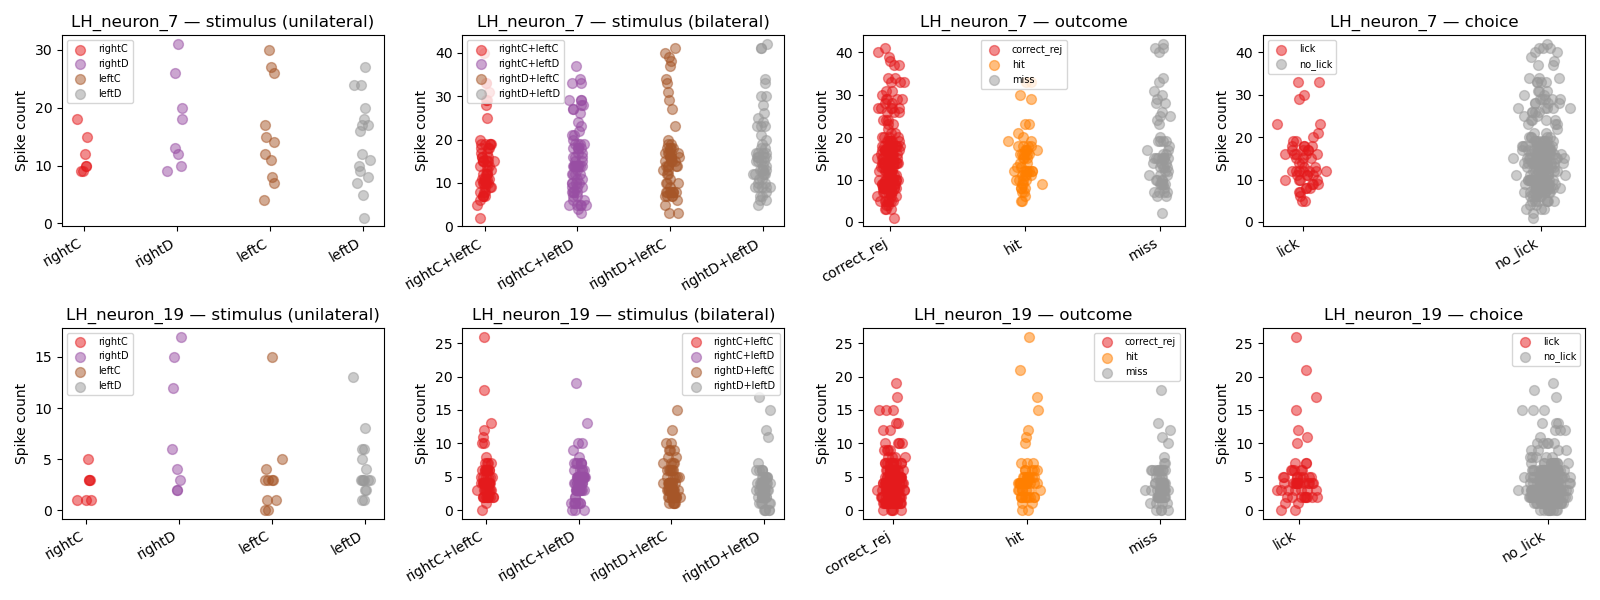

In [7]:
hemi_df, neuron_cols = lh_df, lh_neuron_cols   # switch to (rh_df, rh_neuron_cols) for RH

fig, axes = plt.subplots(len(neuron_cols), len(categorical_panels),
                          figsize=(4 * len(categorical_panels), 3 * len(neuron_cols)),
                          squeeze=False)
for row, neuron_col in enumerate(neuron_cols):
    for col, (var, cats, label) in enumerate(categorical_panels):
        ax = axes[row][col]
        plot_neuron_by_category(hemi_df, neuron_col, var, categories=cats, ax=ax)
        ax.set_title(f'{neuron_col} — {label}')
plt.tight_layout()
plt.show()

## Plot: spike counts vs continuous variable (locomotion, whisker kinematics, lick latency)

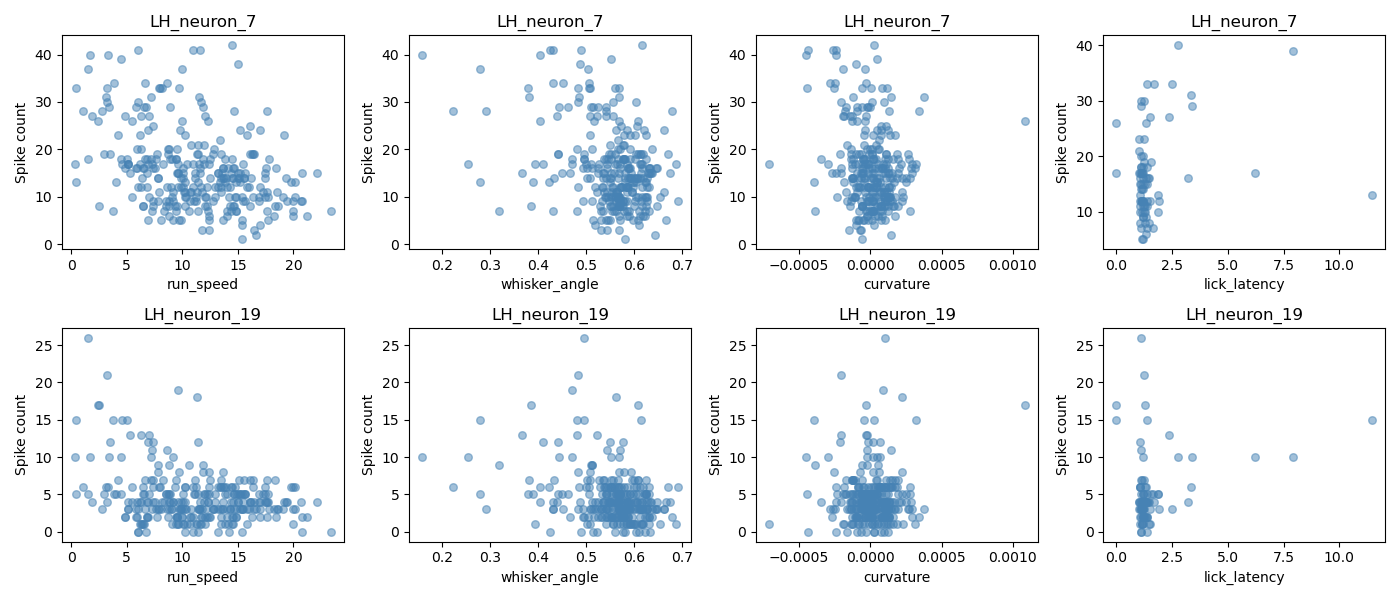

In [8]:
fig, axes = plt.subplots(len(neuron_cols), len(continuous_vars),
                          figsize=(3.5 * len(continuous_vars), 3 * len(neuron_cols)),
                          squeeze=False)
for row, neuron_col in enumerate(neuron_cols):
    for col, var in enumerate(continuous_vars):
        plot_neuron_vs_continuous(hemi_df, neuron_col, var, ax=axes[row][col])
plt.tight_layout()
plt.show()